In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr, mannwhitneyu

print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra"
)

scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra


In [2]:
data = pd.read_csv("~/github/clipnet_k562/siraj_mpra/k562_allelic_mpra_snps.csv.gz")

In [3]:
df = sns.load_dataset('tips')

In [4]:
data["pred"] = np.log2(data["ref"] / data["alt"])
data["pred_procapnet"] = np.log2(data["ref_procapnet_ensemble"] / data["alt_procapnet_ensemble"])
for i in range(7):
    data[f"procapnet_fold_{i}"] = np.log2(data[f"ref_procapnet_fold_{i}"] / data[f"alt_procapnet_fold_{i}"])
data = data[np.isfinite(data["pred"])]
data.dropna(inplace=True)
data = data[data.emVar_K562 == 1]

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [79]:
pearsons = [
    pearsonr(data[data["fold"] == fold]["expt"], data[data["fold"] == fold]["pred"])[0]
    for fold in range(10)
]
pearsons_procapnet = pearsonr(data["expt"], data["pred_procapnet"])[0]
pearsons_procapnet_folds = [pearsonr(data["expt"], data[f"procapnet_fold_{i}"])[0] for i in range(7)]
print(pearsons[0], pearsons_procapnet)

pearsons_plot = pd.DataFrame(pearsons + pearsons_procapnet_folds, index=["CLIPNET -> K562"] * 10 + ["ProCapNet K562"] * 7)
pearsons_plot.reset_index(inplace=True)
pearsons_plot.columns = ["Model", "Pearson (expt vs pred emVar)"]

0.5119878596383289 0.3577710063542904


/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

<Axes: xlabel='Model', ylabel='Pearson (expt vs pred emVar)'>

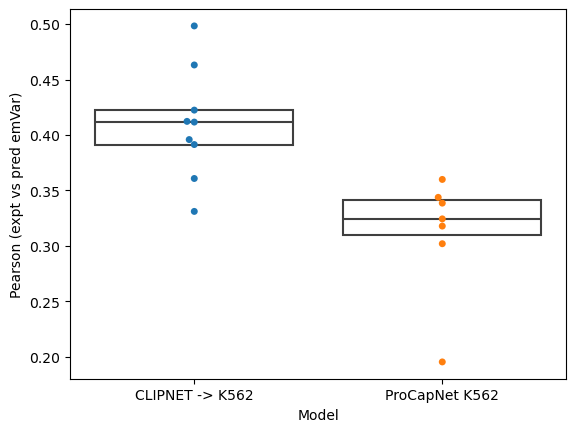

In [80]:
sns.boxplot(
    data=pearsons_plot[1:], x="Model", y="Pearson (expt vs pred emVar)",
    boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':0}, showcaps=False,
)
sns.swarmplot(data=pearsons_plot[1:], x="Model", y="Pearson (expt vs pred emVar)")

In [35]:
mannwhitneyu(pearsons[1:], pearsons_procapnet_folds)

MannwhitneyuResult(statistic=60.0, pvalue=0.0012237762237762239)

In [71]:
signs = [
    (np.sign(data[data.fold == fold].pred) == np.sign(data[data.fold == fold].expt)).mean()
    for fold in range(10)
]
signs_procapnet = (np.sign(data.pred_procapnet) == np.sign(data.expt)).mean()
signs_procapnet_folds = [
    (np.sign(data[f"procapnet_fold_{i}"]) == np.sign(data.expt)).mean()
    for i in range(7)
]

signs_plot = pd.DataFrame(
    signs[1:] + signs_procapnet_folds,
    index=["CLIPNET -> K562"] * 9 + ["ProCapNet K562"] * 7
)
signs_plot.reset_index(inplace=True)
signs_plot.columns = ["Model", "\\% predictions with correct sign"]

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

<Axes: xlabel='Model', ylabel='\\% predictions with correct sign'>

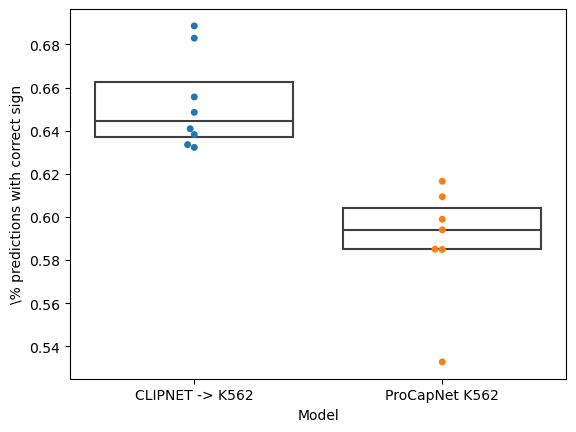

In [73]:
sns.boxplot(
    data=signs_plot[1:], x="Model", y="\\% predictions with correct sign",
    boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':0}, showcaps=False,
)
sns.swarmplot(data=signs_plot[1:], x="Model", y="\\% predictions with correct sign")

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<Axes: xlabel='expt', ylabel='pred_procapnet'>

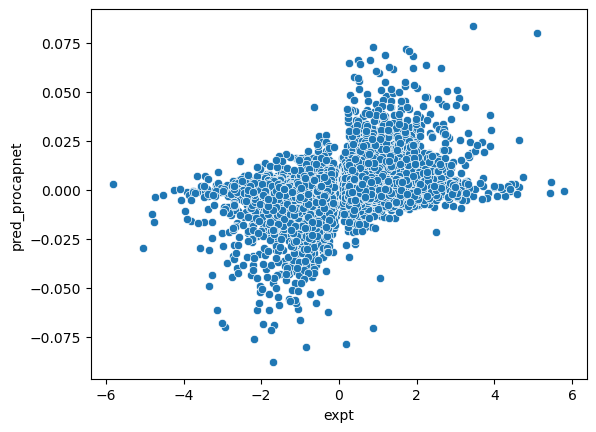

In [51]:
sns.scatterplot(data["expt"], data["pred_procapnet"])

<Axes: xlabel='expt', ylabel='pred'>

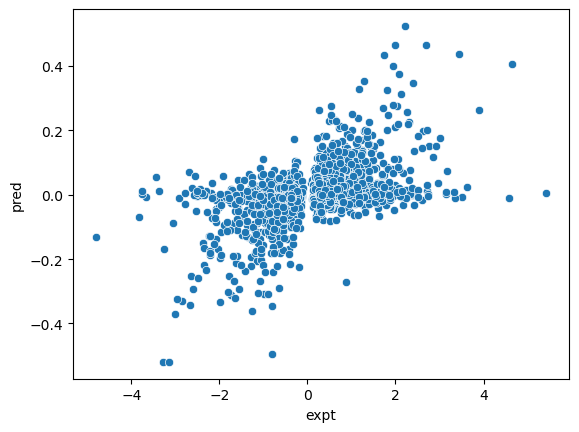

In [74]:
sns.scatterplot(x=data["expt"][data["fold"] == 0], y=data["pred"][data["fold"] == 0])

In [75]:
signs_procapnet

0.6103084021369597

In [77]:
signs[0]

0.7085181898846495

In [78]:
pearsons

[0.5119878596383289,
 0.3913978449728768,
 0.42244589484266476,
 0.39589214820843943,
 0.46313046919356504,
 0.3608130351183288,
 0.41229038482543856,
 0.3311444132375651,
 0.4983257516401296,
 0.41166034006903196]